Nama : Nadir Abika

NIM : 240401010132

Kelas : IF403

Shape: (300, 4)
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


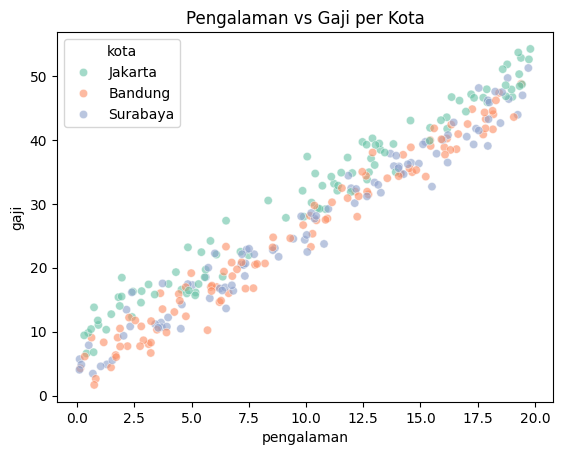

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate dataset sintetis
np.random.seed(42); n = 300
pengalaman = np.random.uniform(0, 20, n)
edu        = np.random.choice([0, 1, 2], n) #SMA=0, D3=1, S1=2
kota       = np.random.choice(['Jakarta', 'Bandung', 'Surabaya'], n)
gaji       = (3.0 + 2.2*pengalaman + 1.5*edu
              + np.where(kota=='Jakarta', 4.0, 0)
              + np.random.normal(0, 2, n))
df = pd.DataFrame({'pengalaman': pengalaman, 'edu': edu, 'kota': kota, 'gaji': gaji})
df.head()

#EDA singkat
print('Shape:', df.shape)
print(df.describe().round(2))

#Scatter: pengalaman vs gaji
sns.scatterplot(data=df, x='pengalaman', y='gaji',
                hue='kota', palette='Set2', alpha=0.6)
plt.title('Pengalaman vs Gaji per Kota')
plt.show()



In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# One-Hot encoding kolom 'kota'
df = pd.get_dummies(df, columns=['kota'],
                    drop_first=True, dtype=int)

# Pisahkan fitur dan target
X = df.drop('gaji', axis=1)
y = df['gaji']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]} baris, Test: {X_test.shape[0]} baris')

#StandartScaler - fit pada training set saja
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)



Train: 240 baris, Test: 60 baris


In [3]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_s, y_train)

# Tampilkan koefisien
print(f'β₀ (intercept): {model.intercept_:.3f}')
print()
coef_df = pd.DataFrame ({
    'Fitur'     : X.columns,
    'Koefisien' : model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)
print(coef_df.to_string(index=False))


β₀ (intercept): 27.514

        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      2.129
          edu      1.188
kota_Surabaya      0.280


In [4]:
from sklearn.metrics import (mean_absolute_error,
                             mean_squared_error, r2_score)

y_pred = model.predict(X_test_s)

mae  = mean_absolute_error(y_test, y_pred)
mse = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('=== Metrik Evaluasi ===')
print(f'MAE:    = {mae:.3f} juta rupiah')
print(f'RMSE:   = {rmse:.3f} juta rupiah')
print(f'R²      = {r2:.4f}    ({r2*100:.1f}% variasi dijelaskan)')
print(f'Selisih RMSE-MAE = {rmse-mae:.3f}')

=== Metrik Evaluasi ===
MAE:    = 1.649 juta rupiah
RMSE:   = 1.284 juta rupiah
R²      = 0.9740    (97.4% variasi dijelaskan)
Selisih RMSE-MAE = -0.365


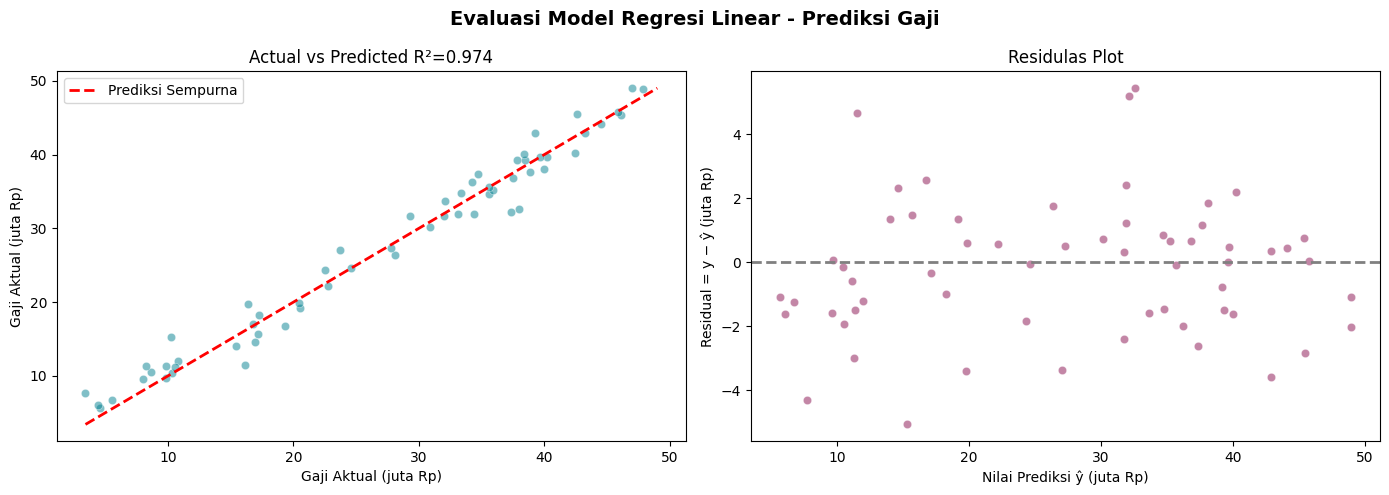

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.5,
                color='#028090', edgecolors='white', lw=0.5)
lims  = [min(y_test.min(), y_pred.min()),
         max(y_test.min(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2,
             label='Prediksi Sempurna')
axes[0].set_xlabel ('Gaji Aktual (juta Rp)')
axes[0].set_ylabel ('Gaji Aktual (juta Rp)')
axes[0].set_title (f'Actual vs Predicted R²={r2:.3f}')
axes[0].legend()

# Plot 2: Residuals
residulas = y_test - y_pred
axes[1].scatter(y_pred, residulas, alpha=0.5,
                color='#880E4F', edgecolors='white', lw=0.5)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y − ŷ (juta Rp)')
axes[1].set_title('Residulas Plot')

plt.suptitle('Evaluasi Model Regresi Linear - Prediksi Gaji',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()